### Introduction to CID for Binary Classification Problems

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
import dice_ml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import CID_numerical
from tqdm import tqdm

### Training the model

It is very important to manage datasets correctly. DiCE requires the dataset containing the target variable in order to be initialised. Conversely, when we carry out training, this variable must be removed. Furthermore, it is advisable that the instances we use for training do not contain the target variable and that the feature names do not include it. 

In [2]:
df = pd.read_csv('diabetes.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Separate into data and outcome 

train_dataset, test_dataset, y_train, y_test = train_test_split(df, df['Outcome'], test_size=0.8, random_state=42)
model = DecisionTreeClassifier()

x_train = train_dataset.drop('Outcome', axis=1)
x_test = test_dataset.drop('Outcome', axis=1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.6552845528455284


> [!WARNING] 
> Dice needs the training dataset with the outcome name

### CID Explanation

In [4]:
CID_explainer = CID_numerical.CIDNumericalExplainer(train_dataset,model,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome')

# Instance we want to explain
instance = x_train[0:1] # <- a pd dataframe

feature_importances = CID_explainer.explain_instance(instance)

100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


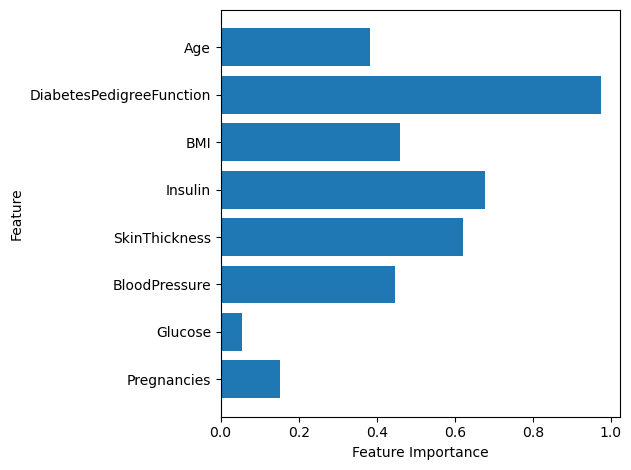

,Feature Importance
Pregnancies,0.151992
Glucose,0.053755
BloodPressure,0.446355
SkinThickness,0.622090
Insulin,0.676419
BMI,0.460085
DiabetesPedigreeFunction,0.974568
Age,0.382782


In [6]:
CID_explainer.visualize_feature_importances(feature_importances,output=True)

In [9]:
CID_explainer.global_explanation()

Explaining instances: 100%|██████████| 30/30 [00:21<00:00,  1.37it/s]


,Feature Importance,Std
Pregnancies,0.286090,0.339413
Glucose,0.417613,0.306945
BloodPressure,0.395126,0.297838
SkinThickness,0.357572,0.290880
Insulin,0.335790,0.254671
BMI,0.389042,0.327644
DiabetesPedigreeFunction,0.480351,0.322575
Age,0.366074,0.343271


## KNeighbors Explanation

In [ ]:
CID_explainer = CID_numerical.CIDNumericalExplainer(train_dataset,model,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome',
                                                    cf_method="neighbors")

# Instance we want to explain
instance = x_train[0:1] # <- a pd dataframe
feature_importances = CID_explainer.explain_instance(instance)


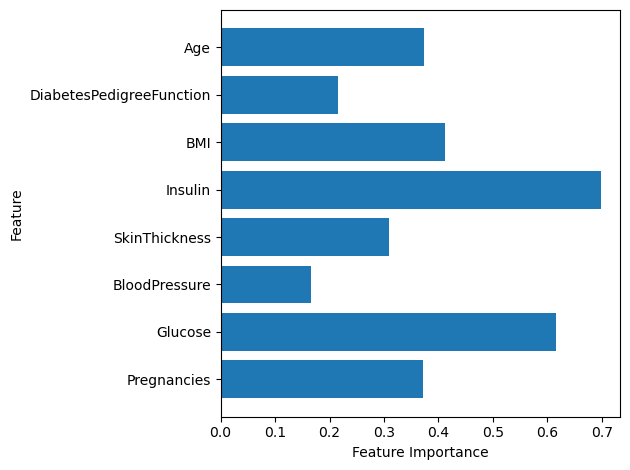

,Feature Importance
Pregnancies,0.371991
Glucose,0.616324
BloodPressure,0.165894
SkinThickness,0.308536
Insulin,0.698611
BMI,0.411794
DiabetesPedigreeFunction,0.215912
Age,0.374419


In [9]:
CID_explainer.visualize_feature_importances(feature_importances,output=True)

In [35]:
import importlib

importlib.reload(CID_numerical)

<module 'CID_numerical' from 'c:\\Users\\econti\\Desktop\\CID_Implementation\\CID_numerical.py'>

## Random Explanation

In [36]:
CID_explainer = CID_numerical.CIDNumericalExplainer(train_dataset,model,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome',
                                                    cf_method="random")


In [38]:
instance = x_train[0:1]
feature_importances = CID_explainer.explain_instance(instance)

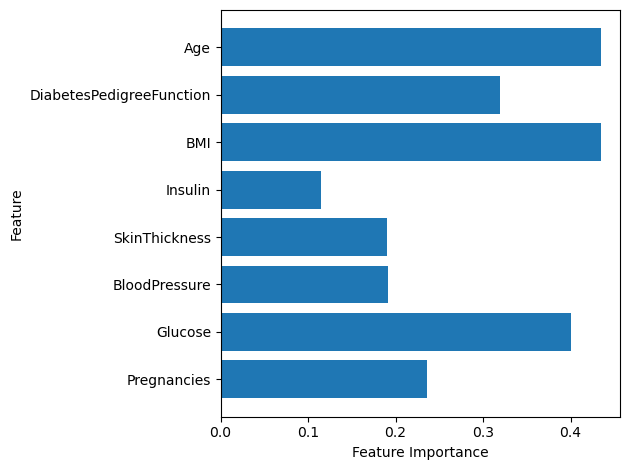

,Feature Importance
Pregnancies,0.235301
Glucose,0.400280
BloodPressure,0.190927
SkinThickness,0.189975
Insulin,0.115211
BMI,0.434734
DiabetesPedigreeFunction,0.318921
Age,0.434690


In [39]:
CID_explainer.visualize_feature_importances(feature_importances,output=True)